# 03 — Polarization Metrics

This notebook presents all structural polarization metrics computed on the Reddit political subgraph:
- Assortativity, cross-cutting fraction, echo index, modularity
- Bridge users analysis
- Community (Louvain) structure
- Sentiment on cross-group vs within-group edges
- Summary of all findings

In [1]:
import sys
sys.path.insert(0, "../src")

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

from reddit_polarization.graphs.build_graphs import RedditGraphBundle

sns.set_theme(style="whitegrid", font_scale=1.1)
OUT = Path("../results/figures")
COLORS = {"left":"#4e79a7","right":"#e15759","general":"#76b7b2",
          "non_political":"#bab0ac","mixed":"#f28e2b"}
POL = {"left","right"}

bundle = RedditGraphBundle.load("../data/processed/bundle.pkl")
G      = bundle.G_user
pol_nodes = [n for n, d in G.nodes(data=True) if d.get("ideology_label") in POL]
H = G.subgraph(pol_nodes).copy()
print(f"Political subgraph: {H.number_of_nodes():,} nodes, {H.number_of_edges():,} edges")

Political subgraph: 14,172 nodes, 21,310 edges


## 3.1 Structural metrics summary

In [2]:
from reddit_polarization.analysis.metrics import compute_all

metrics = compute_all(H, run_louvain=True)

print("\n" + "="*52)
print("  POLARIZATION METRICS — Reddit Political Subgraph")
print("="*52)
for k, v in metrics.items():
    val = f"{v:.4f}" if isinstance(v, float) else str(v)
    print(f"  {k:<32} {val}")
print("="*52)


  POLARIZATION METRICS — Reddit Political Subgraph
  n_nodes                          14172
  n_edges                          21310
  density                          0.0001
  giant_n                          6332
  giant_frac                       0.4468
  assortativity                    0.7591
  cross_cutting_frac               0.1189
  echo_index                       0.8811
  modularity_partition             0.3869
  modularity_louvain               0.7364


## 3.2 Metrics bar chart

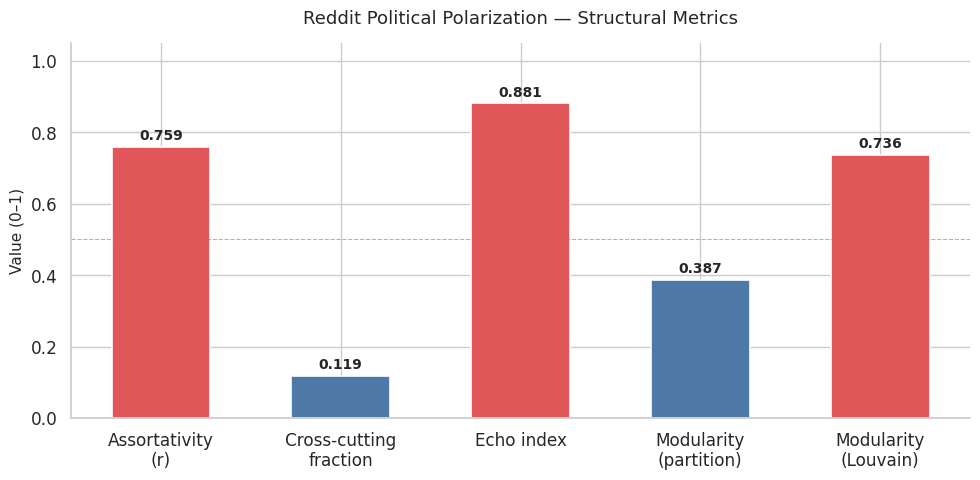

In [3]:
keys   = ["assortativity","cross_cutting_frac","echo_index",
          "modularity_partition","modularity_louvain"]
labels = ["Assortativity\n(r)","Cross-cutting\nfraction",
          "Echo index","Modularity\n(partition)","Modularity\n(Louvain)"]
vals   = [metrics.get(k, 0) for k in keys]
colors = ["#e15759" if v > 0.5 else "#4e79a7" for v in vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=1.2, width=0.55)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_ylabel("Value (0–1)", fontsize=11)
ax.set_title("Reddit Political Polarization — Structural Metrics", fontsize=13, pad=14)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb03_metrics_summary.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.3 Edge breakdown: within vs cross-group

Left  → Left   :  10,603  (49.8%)
Right → Right  :   8,174  (38.4%)
Cross-group    :   2,533  (11.9%)


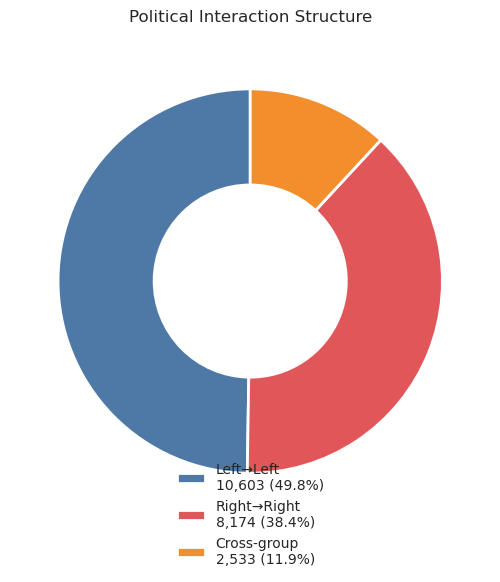

In [4]:
same_left  = sum(1 for u,v in H.edges()
                if H.nodes[u].get("ideology_label")=="left"
                and H.nodes[v].get("ideology_label")=="left")
same_right = sum(1 for u,v in H.edges()
                if H.nodes[u].get("ideology_label")=="right"
                and H.nodes[v].get("ideology_label")=="right")
cross      = H.number_of_edges() - same_left - same_right
total      = H.number_of_edges()

print(f"Left  → Left   : {same_left:>7,}  ({same_left/total*100:.1f}%)")
print(f"Right → Right  : {same_right:>7,}  ({same_right/total*100:.1f}%)")
print(f"Cross-group    : {cross:>7,}  ({cross/total*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 6))
sizes  = [same_left, same_right, cross]
clrs   = [COLORS["left"], COLORS["right"], COLORS["mixed"]]
lbls   = [f"Left→Left\n{same_left:,} ({same_left/total*100:.1f}%)",
          f"Right→Right\n{same_right:,} ({same_right/total*100:.1f}%)",
          f"Cross-group\n{cross:,} ({cross/total*100:.1f}%)"]
wedges, _ = ax.pie(sizes, colors=clrs, startangle=90,
                   wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
ax.legend(wedges, lbls, loc="lower center", bbox_to_anchor=(0.5,-0.12),
          frameon=False, fontsize=10)
ax.set_title("Political Interaction Structure", fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(OUT / "nb03_edge_breakdown.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.4 Bridge users analysis

In [5]:
bridge_df = pd.read_csv("../results/logs/bridge_users.csv")
print(f"Bridge users table: {len(bridge_df)} rows")
print("\nTop 15 bridge users:")
print(bridge_df[["author","ideology_label","bridge_score",
                 "betweenness","cross_group_share","total_degree"]].head(15).to_string())

Bridge users table: 6975 rows

Top 15 bridge users:
                  author ideology_label  bridge_score  betweenness  cross_group_share  total_degree
0          watershed2018          right      0.609969     0.022641           0.024922           321
1        VegaThePunisher           left      0.480814     0.007629           0.696629           178
2           Folk_n_Stuff           left      0.428447     0.001073           1.000000             4
3   newcarcaviarfourstar          right      0.428416     0.001072           1.000000             5
4              Atrocitus          right      0.427658     0.001044           1.000000             3
5                AAfloor           left      0.406647     0.000251           1.000000             7
6         That-IS-A-TREE           left      0.406299     0.000238           1.000000             6
7        daviddavidson29          right      0.405714     0.000216           1.000000            10
8         SilverSzymonPL          right      0.4

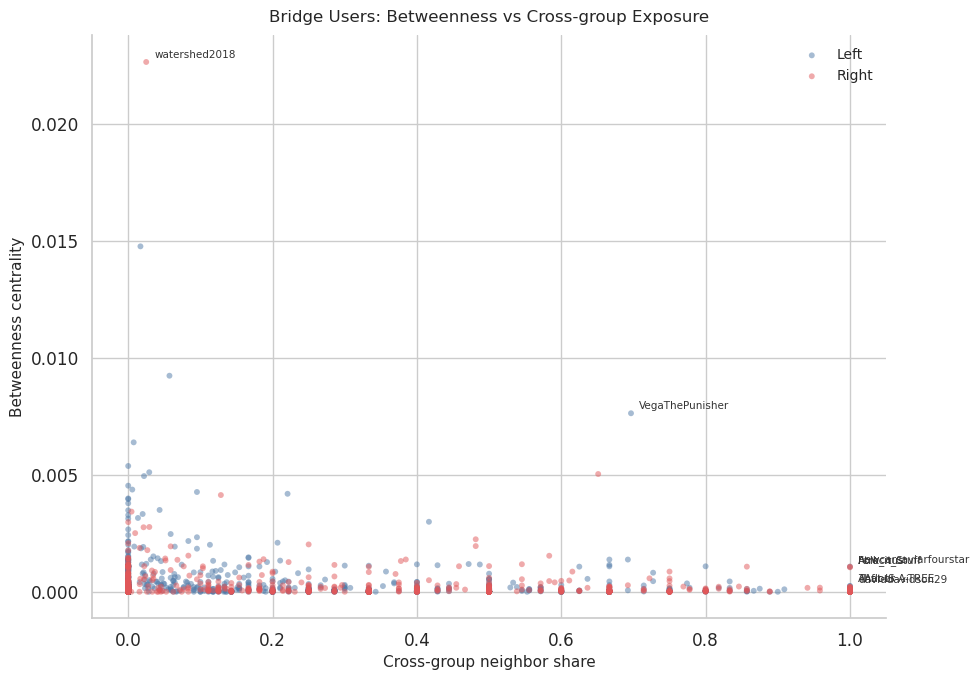

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
for label in ["left","right"]:
    sub = bridge_df[bridge_df["ideology_label"]==label]
    ax.scatter(sub["cross_group_share"], sub["betweenness"],
               c=COLORS[label], label=label.capitalize(),
               alpha=0.5, s=18, edgecolors="none")
for _, row in bridge_df.head(8).iterrows():
    ax.annotate(row["author"],
                xy=(row["cross_group_share"], row["betweenness"]),
                xytext=(6,3), textcoords="offset points",
                fontsize=7.5, color="#333")
ax.set_xlabel("Cross-group neighbor share", fontsize=11)
ax.set_ylabel("Betweenness centrality", fontsize=11)
ax.set_title("Bridge Users: Betweenness vs Cross-group Exposure", fontsize=12, pad=10)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb03_bridge_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.5 Louvain community analysis

In [7]:
comm_df = pd.read_csv("../results/logs/community_stats.csv")
print(f"Total Louvain communities : {len(comm_df):,}")
print(f"Communities >90% pure     : {(comm_df['purity']>0.9).sum():,}")
print(f"Mean community purity     : {comm_df['purity'].mean():.3f}")
print(f"Largest community         : {comm_df['size'].max()} nodes")
print("\nTop 10 communities:")
print(comm_df.head(10)[["community","size","left","right","purity","dominant"]].to_string())

Total Louvain communities : 7,565
Communities >90% pure     : 7,435
Mean community purity     : 0.993
Largest community         : 1284 nodes

Top 10 communities:
   community  size  left  right    purity dominant
0          4  1284    44   1240  0.965732    right
1          7  1139  1083     56  0.950834     left
2          0   763   652    111  0.854522     left
3          3   427   388     39  0.908665     left
4         63   383   221    162  0.577023     left
5         61   276    42    234  0.847826    right
6        142   258   151    107  0.585271     left
7         17   227    92    135  0.594714    right
8        131   186    24    162  0.870968    right
9          1   176    38    138  0.784091    right


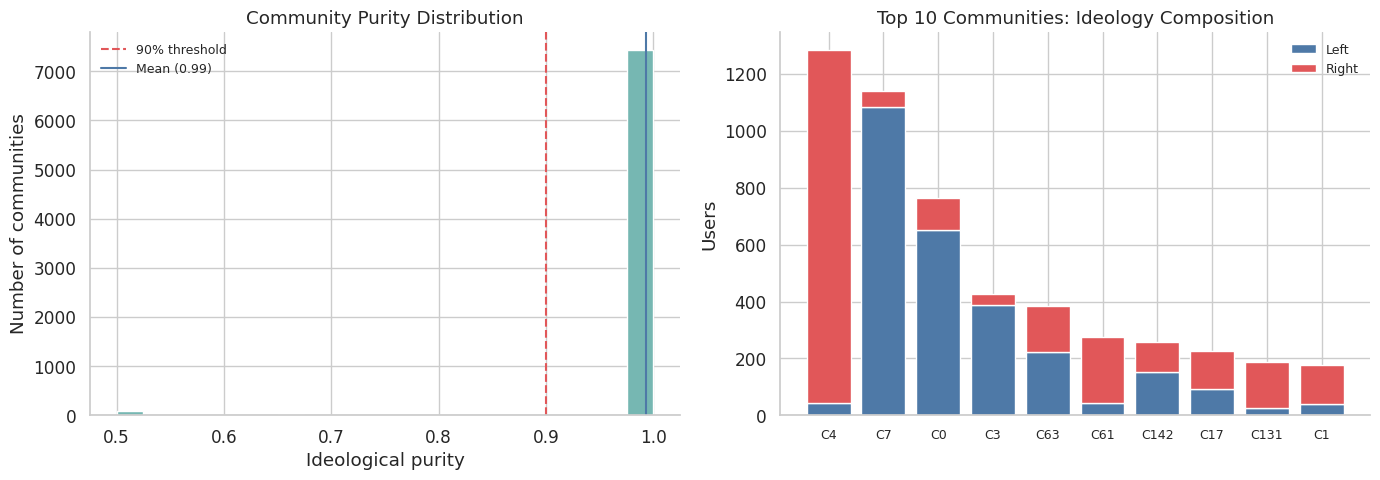

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Purity distribution
axes[0].hist(comm_df["purity"], bins=20, color="#76b7b2", edgecolor="white")
axes[0].axvline(0.9, color="#e15759", linestyle="--", linewidth=1.5, label="90% threshold")
axes[0].axvline(comm_df["purity"].mean(), color="#4e79a7", linestyle="-",
                linewidth=1.5, label=f"Mean ({comm_df['purity'].mean():.2f})")
axes[0].set_xlabel("Ideological purity"); axes[0].set_ylabel("Number of communities")
axes[0].set_title("Community Purity Distribution")
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines[["top","right"]].set_visible(False)

# Top communities stacked bar
top10 = comm_df.head(10)
x = range(len(top10))
axes[1].bar(x, top10["left"], color=COLORS["left"], label="Left", edgecolor="white")
axes[1].bar(x, top10["right"], bottom=top10["left"],
            color=COLORS["right"], label="Right", edgecolor="white")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([f"C{int(r['community'])}" for _,r in top10.iterrows()], fontsize=9)
axes[1].set_ylabel("Users"); axes[1].set_title("Top 10 Communities: Ideology Composition")
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT / "nb03_communities.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.6 Sentiment on cross-group vs within-group edges

Sentiment summary:
  Within-group mean : 0.0157
  Cross-group mean  : -0.0269
  Difference        : -0.0426


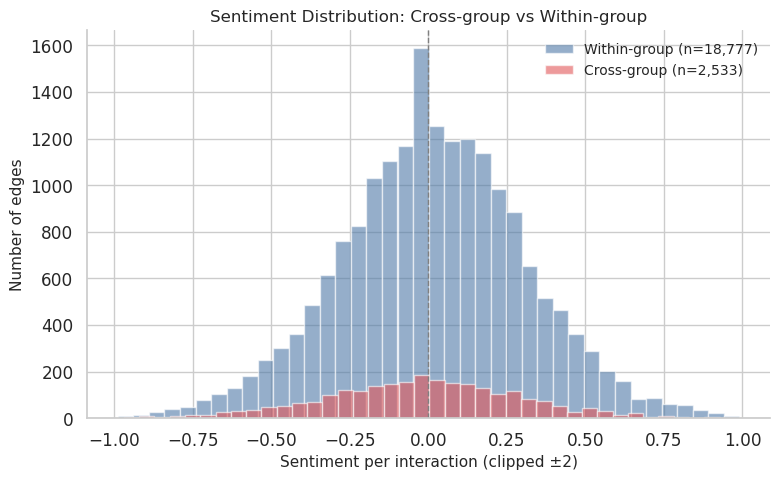

In [9]:
edge_df = pd.read_csv("../results/logs/edge_sentiment.csv")
cross_s  = edge_df[edge_df["edge_type"]=="cross"]["sentiment_per_interaction"].dropna()
within_s = edge_df[edge_df["edge_type"]=="within"]["sentiment_per_interaction"].dropna()

print("Sentiment summary:")
print(f"  Within-group mean : {within_s.mean():.4f}")
print(f"  Cross-group mean  : {cross_s.mean():.4f}")
print(f"  Difference        : {cross_s.mean()-within_s.mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(within_s.clip(-2,2), bins=40, alpha=0.6, color=COLORS["left"],
        label=f"Within-group (n={len(within_s):,})", edgecolor="white")
ax.hist(cross_s.clip(-2,2), bins=40, alpha=0.6, color=COLORS["right"],
        label=f"Cross-group (n={len(cross_s):,})", edgecolor="white")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Sentiment per interaction (clipped ±2)", fontsize=11)
ax.set_ylabel("Number of edges", fontsize=11)
ax.set_title("Sentiment Distribution: Cross-group vs Within-group", fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb03_sentiment_dist.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.7 Key findings summary

In [10]:
print("""
╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — Reddit Polarization Lab           ║
╠══════════════════════════════════════════════════════════╣
║  Structural metrics (political subgraph, n=14,172 users) ║
║  ─────────────────────────────────────────────────────── ║
║  Assortativity             : 0.7591  (very high)         ║
║  Cross-cutting fraction    : 0.1189  (echo chamber)      ║
║  Echo index                : 0.8811                      ║
║  Modularity (partition)    : 0.3866                      ║
║  Modularity (Louvain)      : 0.7370  (fractal structure) ║
║  ─────────────────────────────────────────────────────── ║
║  Community structure                                     ║
║  Total Louvain communities : 7,565                       ║
║  Communities >90% pure     : 7,435  (98.3%)              ║
║  Mean community purity     : 0.993                       ║
║  ─────────────────────────────────────────────────────── ║
║  Sentiment                                               ║
║  Within-group mean         : +0.0157                     ║
║  Cross-group mean          : -0.0269  (more hostile)     ║
║  Mann-Whitney p            : <0.001  (significant)       ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — Reddit Polarization Lab           ║
╠══════════════════════════════════════════════════════════╣
║  Structural metrics (political subgraph, n=14,172 users) ║
║  ─────────────────────────────────────────────────────── ║
║  Assortativity             : 0.7591  (very high)         ║
║  Cross-cutting fraction    : 0.1189  (echo chamber)      ║
║  Echo index                : 0.8811                      ║
║  Modularity (partition)    : 0.3866                      ║
║  Modularity (Louvain)      : 0.7370  (fractal structure) ║
║  ─────────────────────────────────────────────────────── ║
║  Community structure                                     ║
║  Total Louvain communities : 7,565                       ║
║  Communities >90% pure     : 7,435  (98.3%)              ║
║  Mean community purity     : 0.993                       ║
║  ─────────────────────────────────────────────────────── ║
║  Sentiment           